In [1]:
!python --version

Python 3.12.3


In [22]:
import json
import matplotlib.pyplot as plt
import os
import numpy as np

In [8]:
print(os.getcwd())

result_path = os.path.join(os.getcwd(), "..", "data")
print(result_path)
print(os.listdir(result_path))

/workspaces/3DGS/Source/metrics_checker_3dgs/src
/workspaces/3DGS/Source/metrics_checker_3dgs/src/../data
['results.json']


In [13]:
with open(os.path.join(result_path, "results.json"), 'r', encoding='utf-8') as file:
    data = json.load(file)

In [14]:
print(data)

{'ours_1': {'SSIM': 0.08742482215166092, 'PSNR': 9.915569305419922, 'LPIPS': 0.48833948373794556}, 'ours_10': {'SSIM': 0.09003540128469467, 'PSNR': 11.116205215454102, 'LPIPS': 0.44860169291496277}, 'ours_100': {'SSIM': 0.29350554943084717, 'PSNR': 19.501249313354492, 'LPIPS': 0.1699354499578476}, 'ours_1000': {'SSIM': 0.9519104361534119, 'PSNR': 28.945039749145508, 'LPIPS': 0.059891801327466965}, 'ours_10000': {'SSIM': 0.9862229228019714, 'PSNR': 34.67595672607422, 'LPIPS': 0.021898625418543816}, 'ours_2000': {'SSIM': 0.9639125466346741, 'PSNR': 30.04350471496582, 'LPIPS': 0.044205352663993835}, 'ours_50': {'SSIM': 0.1177840530872345, 'PSNR': 16.044034957885742, 'LPIPS': 0.272995263338089}, 'ours_500': {'SSIM': 0.9312610030174255, 'PSNR': 26.678829193115234, 'LPIPS': 0.08213743567466736}, 'ours_5000': {'SSIM': 0.9820664525032043, 'PSNR': 33.582054138183594, 'LPIPS': 0.026905737817287445}}


In [27]:
ssim_values = {}
psnr_values = {}
lpips_values = {}

iterations = []

for result in data:
    iterations.append(int(result.split('_')[1]))
    ssim_values[iterations[-1]] = (data[result]["SSIM"])
    psnr_values[iterations[-1]] = (data[result]["PSNR"])
    lpips_values[iterations[-1]] = (data[result]["LPIPS"])


sorted_keys = sorted(iterations)
print("Sample sizes:", sorted_keys)
print("SSIM values:", [ssim_values[k] for k in sorted_keys])
print("PSNR values:", [psnr_values[k] for k in sorted_keys])
print("LPIPS values:", [lpips_values[k] for k in sorted_keys])

Sample sizes: [1, 10, 50, 100, 500, 1000, 2000, 5000, 10000]
SSIM values: [0.08742482215166092, 0.09003540128469467, 0.1177840530872345, 0.29350554943084717, 0.9312610030174255, 0.9519104361534119, 0.9639125466346741, 0.9820664525032043, 0.9862229228019714]
PSNR values: [9.915569305419922, 11.116205215454102, 16.044034957885742, 19.501249313354492, 26.678829193115234, 28.945039749145508, 30.04350471496582, 33.582054138183594, 34.67595672607422]
LPIPS values: [0.48833948373794556, 0.44860169291496277, 0.272995263338089, 0.1699354499578476, 0.08213743567466736, 0.059891801327466965, 0.044205352663993835, 0.026905737817287445, 0.021898625418543816]


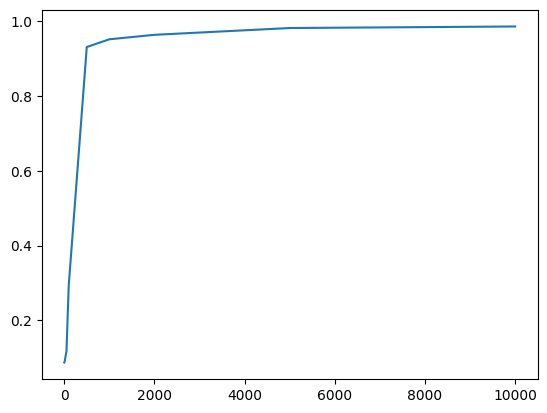

In [30]:
plt.plot(sorted_keys, [ssim_values[k] for k in sorted_keys])
plt.show()

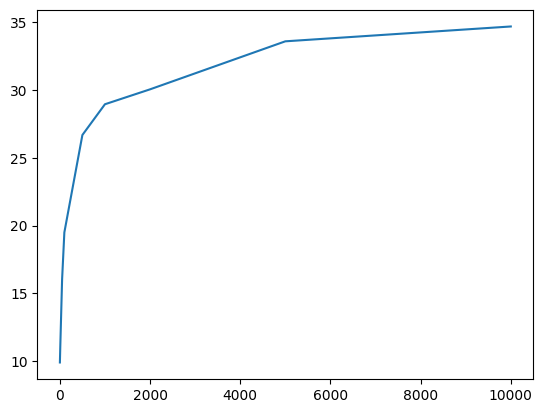

In [31]:
plt.plot(sorted_keys, [psnr_values[k] for k in sorted_keys])
plt.show()

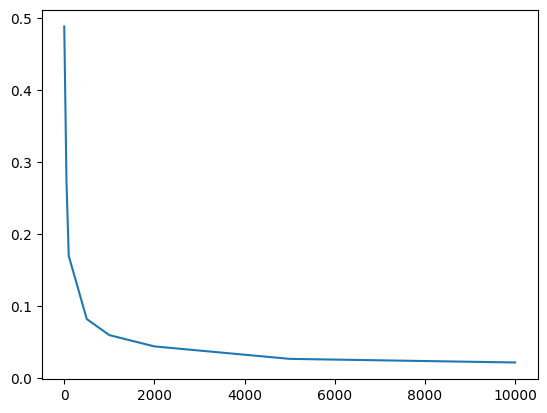

In [ ]:
plt.plot(sorted_keys, [lpips_values[k] for k in sorted_keys])
plt.xlabel("Кол-во итераций")
plt.ylabel("LPIPS")
plt.show()